In [66]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "ID": [1, 2, 3, 4, 5],
    "Nombre": ["Juan", "María", "Pedro", "Ana", "Luis"],
    "Edad": [32, -28, 40, 35, 50],
    "Nivel_Educativo": ["Licenciado", "Ingeniero", "Doctorado", "Licenciado", "Doctorado"],
    "Salario": [50000, 60000, None, 55000, 200000],
    "Categoria": ["Junior", "Senior", "Senior", "Junior", "Manager"],
    "Estado": ["Activo", "ACTIVO", "Inactivo", "Activo", "Inactivo"]
})

df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,-28,Ingeniero,60000.0,Senior,ACTIVO
2,3,Pedro,40,Doctorado,NaN,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


# AO1 Clase 2 – Limpieza, Transformación y Análisis Exploratorio de Datos con LLMs

## 1. Carga de datos

En esta primera etapa se construye el dataset con los datos proporcionados en la consigna para comenzar el análisis.

In [67]:
print("Información general del dataset:")
print(df.info())

print("\nResumen descriptivo:")
print(df.describe(include="all"))

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               5 non-null      int64  
 1   Nombre           5 non-null      object 
 2   Edad             5 non-null      int64  
 3   Nivel_Educativo  5 non-null      object 
 4   Salario          4 non-null      float64
 5   Categoria        5 non-null      object 
 6   Estado           5 non-null      object 
dtypes: float64(1), int64(2), object(4)
memory usage: 412.0+ bytes
None

Resumen descriptivo:
              ID Nombre      Edad Nivel_Educativo        Salario Categoria  \
count   5.000000      5   5.00000               5       4.000000         5   
unique       NaN      5       NaN               3            NaN         3   
top          NaN   Juan       NaN      Licenciado            NaN    Junior   
freq         NaN      1       NaN              

## 2. Observación inicial del conjunto de datos

En esta etapa se revisa la estructura general del dataset para identificar posibles problemas de calidad, como valores faltantes, datos inconsistentes o registros que necesiten corrección antes del análisis.

## 3. Clasificación de las variables

- **ID:** dato numérico entero. Funciona como identificador.
- **Nombre:** dato categórico nominal. Se usa solo como referencia.
- **Edad:** dato numérico.
- **Nivel_Educativo:** variable categórica ordinal, porque hay jerarquía entre niveles.
- **Salario:** variable numérica continua.
- **Categoria:** variable categórica ordinal, porque representa niveles dentro del trabajo.
- **Estado:** variable categórica nominal, porque indica una condición del empleado.

In [68]:
print("Cantidad de valores faltantes por columna:")
print(df.isnull().sum())

print("\nRegistros con edad inválida:")
print(df[df["Edad"] < 0])

print("\nCantidad de filas duplicadas:")
print(df.duplicated().sum())

print("\nValores encontrados en la columna Estado:")
print(df["Estado"].unique())

Cantidad de valores faltantes por columna:
ID                 0
Nombre             0
Edad               0
Nivel_Educativo    0
Salario            1
Categoria          0
Estado             0
dtype: int64

Registros con edad inválida:
   ID Nombre  Edad Nivel_Educativo  Salario Categoria  Estado
1   2  María   -28       Ingeniero  60000.0    Senior  ACTIVO

Cantidad de filas duplicadas:
0

Valores encontrados en la columna Estado:
['Activo' 'ACTIVO' 'Inactivo']


## 4. Limpieza de datos

A partir del diagnóstico inicial, se detectaron tres problemas principales:

1. Una edad con valor negativo.
2. Un salario faltante.
3. Inconsistencias en la variable categórica Estado.

Para resolverlos:
- la edad negativa se corrige usando valor absoluto,
- el salario faltante se reemplaza por la mediana,
- y los valores de Estado se unifican para que tengan el mismo formato.

In [69]:
df["Edad"] = df["Edad"].abs()
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,28,Ingeniero,60000.0,Senior,ACTIVO
2,3,Pedro,40,Doctorado,NaN,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


In [70]:
df["Salario"] = df["Salario"].fillna(df["Salario"].median())
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,28,Ingeniero,60000.0,Senior,ACTIVO
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


In [71]:
df["Estado"] = df["Estado"].str.capitalize()
print(df["Estado"].unique())
df

['Activo' 'Inactivo']


,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,28,Ingeniero,60000.0,Senior,Activo
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


## 5. Detección de valores atípicos en Salario

Para identificar posibles outliers en la variable Salario, se utiliza el método del rango intercuartílico (IQR). Este procedimiento permite detectar valores demasiado alejados del resto de la distribución.

In [72]:
Q1 = df["Salario"].quantile(0.25)
Q3 = df["Salario"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Primer cuartil (Q1):", Q1)
print("Tercer cuartil (Q3):", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

print("\nPosibles outliers:")
print(df[(df["Salario"] < limite_inferior) | (df["Salario"] > limite_superior)])

Primer cuartil (Q1): 55000.0
Tercer cuartil (Q3): 60000.0
IQR: 5000.0
Límite inferior: 47500.0
Límite superior: 67500.0

Posibles outliers:
   ID Nombre  Edad Nivel_Educativo   Salario Categoria    Estado
4   5   Luis    50       Doctorado  200000.0   Manager  Inactivo


In [73]:
df = df[(df["Salario"] >= limite_inferior) & (df["Salario"] <= limite_superior)].copy()
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,28,Ingeniero,60000.0,Senior,Activo
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo


## 6. Transformación de variables

Una vez realizada la limpieza, se transforman algunas variables para facilitar su análisis:

- Nivel_Educativo se convierte a formato numérico mediante codificación ordinal.
- Categoria también se codifica de forma ordinal.
- Estado se transforma en una variable binaria.
- Salario se normaliza para llevarlo a una escala comparable.
- Se crea una nueva variable llamada Anios_Hasta_Jubilacion.

In [74]:
encoder_nivel = OrdinalEncoder(categories=[["Licenciado", "Ingeniero", "Doctorado"]])
df["Nivel_Cod"] = encoder_nivel.fit_transform(df[["Nivel_Educativo"]])
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado,Nivel_Cod
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0


In [75]:
encoder_categoria = OrdinalEncoder(categories=[["Junior", "Senior", "Manager"]])
df["Categoria_Cod"] = encoder_categoria.fit_transform(df[["Categoria"]])
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado,Nivel_Cod,Categoria_Cod
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0


In [76]:
df["Estado_Cod"] = df["Estado"].map({"Activo": 1, "Inactivo": 0})
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado,Nivel_Cod,Categoria_Cod,Estado_Cod
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0,1
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0,1
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0,0
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0,1


In [77]:
scaler = MinMaxScaler()
df["Salario_Normalizado"] = scaler.fit_transform(df[["Salario"]])
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado,Nivel_Cod,Categoria_Cod,Estado_Cod,Salario_Normalizado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0,1,0.00
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0,1,1.00
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0,0,0.75
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0,1,0.50


In [78]:
df["Anios_Hasta_Jubilacion"] = 65 - df["Edad"]
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado,Nivel_Cod,Categoria_Cod,Estado_Cod,Salario_Normalizado,Anios_Hasta_Jubilacion
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0,1,0.00,33
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0,1,1.00,37
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0,0,0.75,25
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0,1,0.50,30


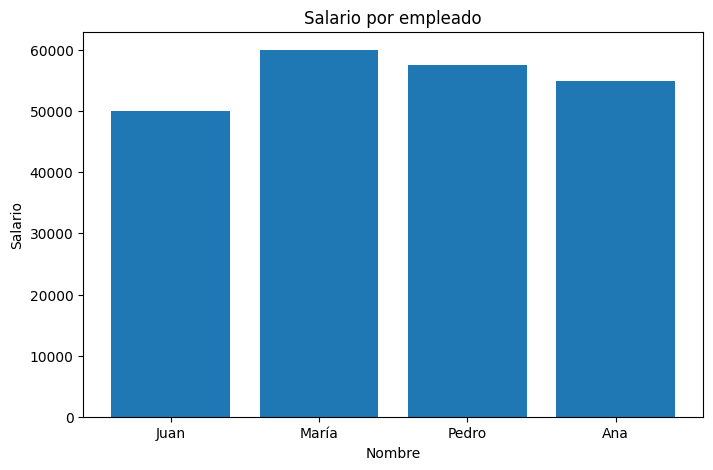

In [79]:
plt.figure(figsize=(8,5))
plt.bar(df["Nombre"], df["Salario"])
plt.title("Salario por empleado")
plt.xlabel("Nombre")
plt.ylabel("Salario")
plt.show()

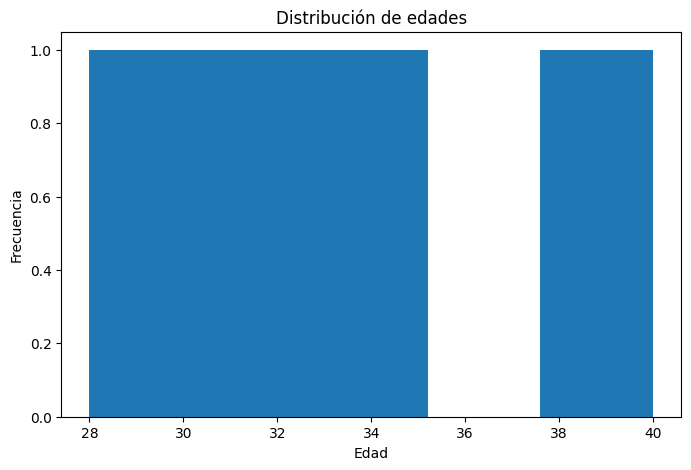

In [80]:
plt.figure(figsize=(8,5))
plt.hist(df["Edad"], bins=5)
plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

## 7. Análisis exploratorio de datos (EDA)

A partir de las visualizaciones se puede observar que, luego de la limpieza, los salarios presentan una distribución más homogénea y sin valores extremos. También se observa que las edades del conjunto analizado se concentran entre los 28 y 40 años. Estas visualizaciones ayudan a comprender mejor la estructura del dataset antes de aplicar modelos de minería de datos.

## 8. Uso de LLM (ChatGPT)

Para apoyar el desarrollo de la actividad, se utilizó ChatGPT como herramienta de consulta.

### Prompt 1
Tengo un dataset con sueldos y edades, ¿cómo puedo detectar y eliminar outliers en Python?

**Síntesis:** ChatGPT sugirió utilizar el método IQR para detectar valores atípicos. También explicó cómo calcular los cuartiles, los límites y cómo filtrar los registros extremos. Esta sugerencia fue útil y se aplicó correctamente en el notebook.

### Prompt 2
¿Cómo puedo convertir variables categóricas en numéricas en Python?

**Síntesis:** ChatGPT explicó que se pueden usar técnicas como codificación ordinal y transformación binaria según el tipo de variable. Esta orientación ayudó a decidir cómo transformar Nivel_Educativo, Categoria y Estado. Luego se revisó y aplicó en el trabajo.

## 9. Conclusión

En esta actividad se identificaron los tipos de datos del dataset, se corrigieron errores de calidad, se eliminaron valores atípicos, se transformaron variables categóricas en numéricas y se realizaron visualizaciones básicas. Todo esto permitió preparar correctamente los datos para un análisis de minería de datos más confiable.
